<a href="https://colab.research.google.com/github/hind190/Data-Mining-Project-/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[1] Problem**
The goal of this project is to analyze garment factory data to improve productivity.
We aim to predict productivity levels and discover patterns using data mining techniques.
This is important because improving productivity helps optimize operations and resource usage.

**Why Is This Important?**
Analyzing garment worker productivity is important because it provides a data-driven understanding of how real working conditions shape performance inside a factory. Instead of relying on assumptions or arbitrary target-setting, this project reveals the actual factors that influence productivity and how employee groups naturally behave. Its importance can be summarized through three clear contributions:


*   **Identifying the true drivers of productivity:** By examining attributes such as SMV, over_time, wip, idle_time, and team structure, the project uncovers which conditions most strongly affect a worker’s ability to meet targets—something factory management often cannot see directly.

*   **Exposing hidden performance patterns**: Clustering helps reveal natural groupings among workers and teams based on their operational behavior. These patterns highlight differences in workload, conditions, and efficiency that are not captured by a simple productivity label.
*   **Enabling fairer and more informed decision-making:** The insights gained allow for more realistic target setting, better resource allocation, and more equitable incentive systems, ultimately reducing the disconnect between management expectations and day-to-day factory realities.




#**[2] Data Mining Tasks**
The problem is formulated as both a classification and clustering task.




## **1.**   **Classification:**
Predict productivity class (Low, Medium, High)

**Classification Goal:**

 The objective of the classification task is to build a model capable of predicting a team’s productivity category (Low, Medium, or High) using the recorded factory features such as SMV, over_time, wip, incentive, idle_time, department, and team-related characteristics. Once trained, the model can be used to estimate whether a team is likely to meet or fall short of its productivity targets. This helps factory managers identify low-performing teams early, understand the conditions contributing to reduced productivity, and make more informed decisions to improve efficiency on the production floor.

---
## **2.**    **Clustering:**
For clustering, the model will group employees with similar productivity patterns. These clusters will be used to predict results for new employees based on the group they are most similar to, helping better manage employee performance.

**Clustering Goal:**

The goal of the clustering task is to group garment factory teams into meaningful clusters based on their productivity patterns and operational characteristics. By identifying teams that share similar working conditions such as overtime levels, idle time, workload, or incentive response the clustering process uncovers natural subgroups within the factory that are not visible through predefined labels. These clusters help management understand how different types of teams operate, enabling more targeted interventions, smarter resource allocation, and performance strategies tailored to each group’s specific needs.

#**[3] Data**
The dataset contains information about garment production including attributes such as department, team, incentives, working hours, and productivity.

The target variable is actual_productivity, which was later discretized into categories.

#**[4] Data Preprocessing**
Several preprocessing techniques were applied:

- Handling missing values (e.g., WIP column)
- Noise removal using IQR method
- Discretization of productivity into classes
- Normalization using MinMaxScaler

These steps improved data quality and prepared it for modeling.

# **[5] Data Mining Technique**
Two techniques were applied:

1. Decision Tree Classification using:
   - Gini index
   - Entropy

2. K-Means Clustering using different values of K (2, 3, 4)

The models were implemented using Python and Scikit-learn.

## **Decision Tree Classification using Gini Index**
In this section, we applied Decision Tree classification using the Gini index as the attribute selection measure.

The dataset was split into three different training and testing partitions:


*   90% training and 10% testing

*   80% training and 20% testing
*   70% training and 30% testing

For each split, the model was trained and evaluated using accuracy and confusion matrix.



In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [22]:
df = pd.read_csv("Preprocessed_dataset.csv")

In [24]:
df["productivity_class"] = pd.cut(
    df["actual_productivity"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [25]:
X = df.drop(["productivity_class", "date"], axis=1)
y = df["productivity_class"]

In [26]:
X = pd.get_dummies(X, drop_first=True)

Accuracy (90/10): 1.0


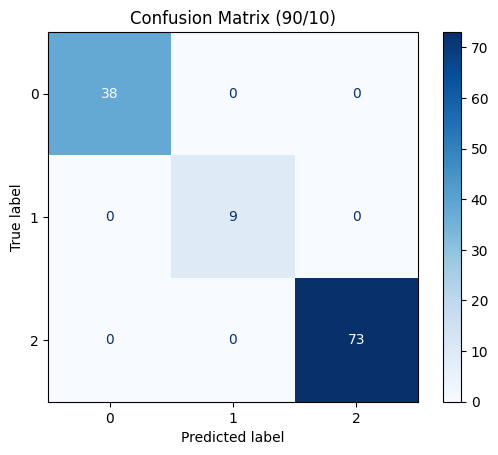

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model_90 = DecisionTreeClassifier(criterion="gini", random_state=42)
model_90.fit(X_train, y_train)

y_pred_90 = model_90.predict(X_test)

acc_90 = accuracy_score(y_test, y_pred_90)
print("Accuracy (90/10):", acc_90)

cm_90 = confusion_matrix(y_test, y_pred_90)
ConfusionMatrixDisplay(cm_90).plot(cmap="Blues")
plt.title("Confusion Matrix (90/10)")
plt.show()

Accuracy (80/20): 1.0


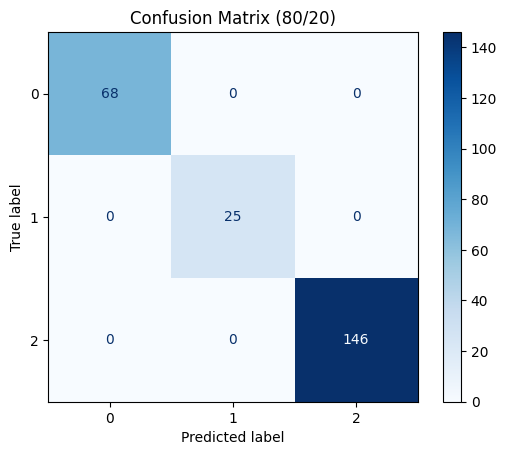

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_80 = DecisionTreeClassifier(criterion="gini", random_state=42)
model_80.fit(X_train, y_train)

y_pred_80 = model_80.predict(X_test)

acc_80 = accuracy_score(y_test, y_pred_80)
print("Accuracy (80/20):", acc_80)

cm_80 = confusion_matrix(y_test, y_pred_80)
ConfusionMatrixDisplay(cm_80).plot(cmap="Blues")
plt.title("Confusion Matrix (80/20)")
plt.show()

Accuracy (70/30): 1.0


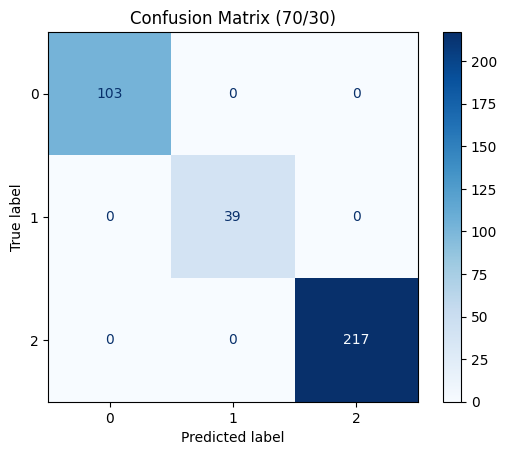

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_70 = DecisionTreeClassifier(criterion="gini", random_state=42)
model_70.fit(X_train, y_train)

y_pred_70 = model_70.predict(X_test)

acc_70 = accuracy_score(y_test, y_pred_70)
print("Accuracy (70/30):", acc_70)

cm_70 = confusion_matrix(y_test, y_pred_70)
ConfusionMatrixDisplay(cm_70).plot(cmap="Blues")
plt.title("Confusion Matrix (70/30)")
plt.show()

In [31]:
results = pd.DataFrame({
    "Split": ["90/10", "80/20", "70/30"],
    "Accuracy": [acc_90, acc_80, acc_70]
})

print(results)

   Split  Accuracy
0  90/10       1.0
1  80/20       1.0
2  70/30       1.0


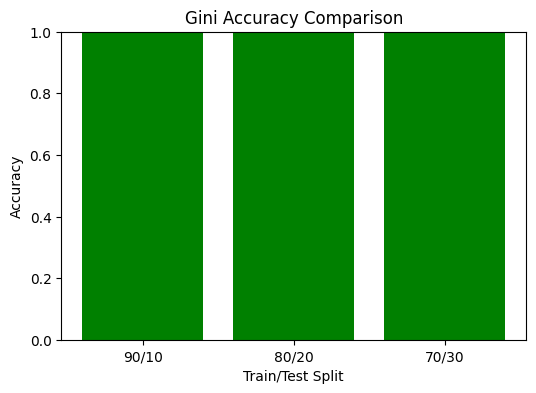

In [32]:
plt.figure(figsize=(6,4))
plt.bar(results["Split"], results["Accuracy"], color="green")
plt.title("Gini Accuracy Comparison")
plt.xlabel("Train/Test Split")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


The Decision Tree classifier using the Gini index was evaluated using three different train-test splits (90/10, 80/20, and 70/30).

The model achieved an accuracy of 1.0 (100%) across all splits. The confusion matrices show that all instances were correctly classified into their respective classes.

This indicates that the model performed extremely well on the dataset.

Gini Results:

*   90/10 split accuracy = 1.0
*   80/20 split accuracy = 1.0

*   70/30 split accuracy = 1.0


Although the model achieved perfect accuracy, this may indicate overfitting.

Overfitting occurs when the model memorizes the training data instead of learning general patterns. As a result, the model may not perform well on unseen data.

This suggests that further validation or testing with different models may be required to ensure generalization.

The Gini index was used to measure impurity and select the best splits during the construction of the decision tree.

All three splits produced the same accuracy, indicating that the model performance is consistent regardless of the training size.

However, increasing the training data generally helps improve model learning, but in this case, the model may already be overfitting the dataset.


## **Decision Tree Classification using Entropy**
In this section, we applied Decision Tree classification using Entropy as the attribute selection measure.

The dataset was split into three different training and testing partitions:


*   90% training and 10% testing

*   80% training and 20% testing
*   70% training and 30% testing
For each split, the model was trained and evaluated using accuracy and confusion matrix.



Accuracy (90/10): 1.0


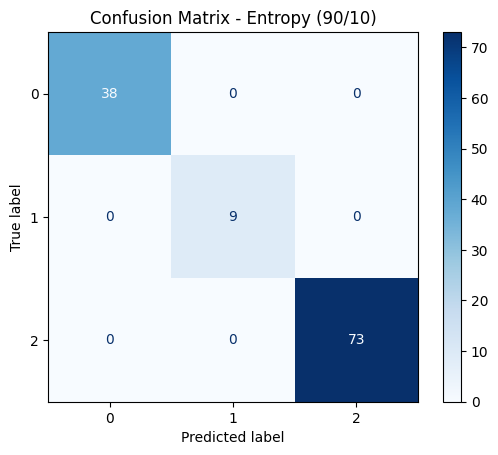

In [33]:
# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

model_entropy_90 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_90.fit(X_train, y_train)

y_pred_90 = model_entropy_90.predict(X_test)

acc_entropy_90 = accuracy_score(y_test, y_pred_90)
print("Accuracy (90/10):", acc_entropy_90)

cm_entropy_90 = confusion_matrix(y_test, y_pred_90)
ConfusionMatrixDisplay(confusion_matrix=cm_entropy_90).plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy (90/10)")
plt.show()


Accuracy (80/20): 1.0


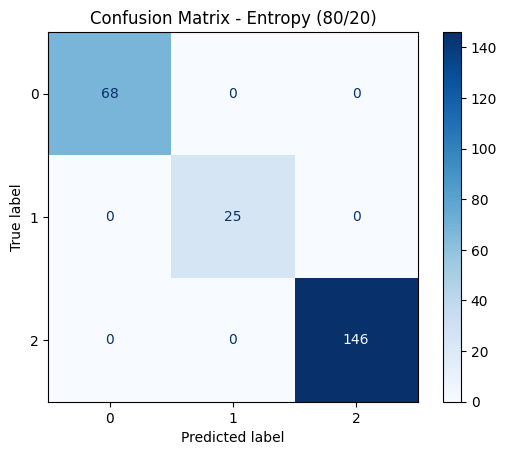

In [34]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_entropy_80 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_80.fit(X_train, y_train)

y_pred_80 = model_entropy_80.predict(X_test)

acc_entropy_80 = accuracy_score(y_test, y_pred_80)
print("Accuracy (80/20):", acc_entropy_80)

cm_entropy_80 = confusion_matrix(y_test, y_pred_80)
ConfusionMatrixDisplay(confusion_matrix=cm_entropy_80).plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy (80/20)")
plt.show()

Accuracy (70/30): 1.0


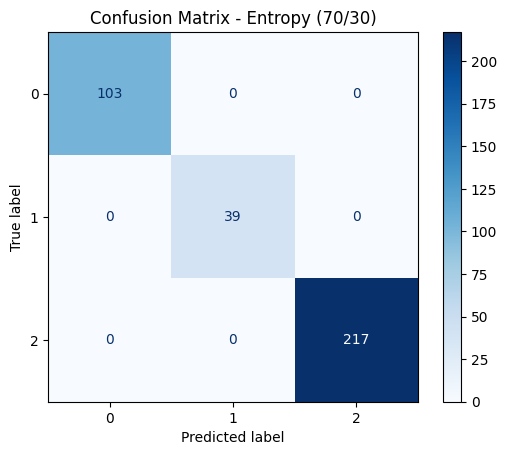

In [37]:
# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model_entropy_70 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_70.fit(X_train, y_train)

y_pred_70 = model_entropy_70.predict(X_test)

acc_entropy_70 = accuracy_score(y_test, y_pred_70)
print("Accuracy (70/30):", acc_entropy_70)

cm_entropy_70 = confusion_matrix(y_test, y_pred_70)
ConfusionMatrixDisplay(confusion_matrix=cm_entropy_70).plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy (70/30)")
plt.show()

In [38]:
entropy_results = pd.DataFrame({
    "Split": ["90/10", "80/20", "70/30"],
    "Accuracy": [acc_entropy_90, acc_entropy_80, acc_entropy_70]
})

print(entropy_results)

   Split  Accuracy
0  90/10       1.0
1  80/20       1.0
2  70/30       1.0


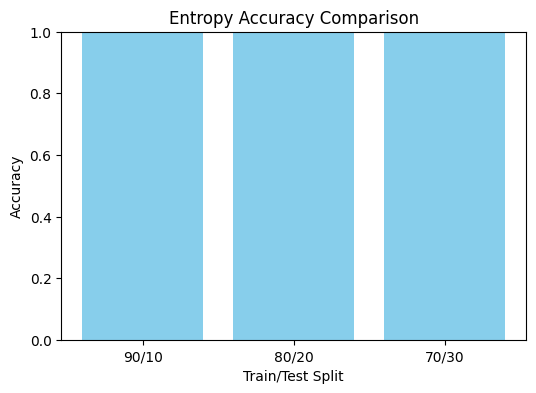

In [39]:
plt.figure(figsize=(6,4))
plt.bar(entropy_results["Split"], entropy_results["Accuracy"], color="skyblue")
plt.title("Entropy Accuracy Comparison")
plt.xlabel("Train/Test Split")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

The Decision Tree classifier using Entropy was evaluated using three different train-test splits (90/10, 80/20, and 70/30).

The model achieved an accuracy of 1.0 (100%) across all splits. The confusion matrices show that all instances were correctly classified into their respective classes.

This indicates that the model performed extremely well on the dataset.

Although the model achieved perfect accuracy, this may indicate overfitting.

Overfitting occurs when the model memorizes the training data instead of learning general patterns. As a result, the model may not perform well on unseen data.

In [41]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv("Preprocessed_dataset.csv")

In [43]:
df = df.drop(["date"], axis=1, errors='ignore')
df = pd.get_dummies(df, drop_first=True)

df = df.fillna(df.mean())

Remove unnecessary columns and convert categorical data to numerical.

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [47]:
wcss = []
K_range = [2, 3, 4]

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Compute WCSS for different K values.

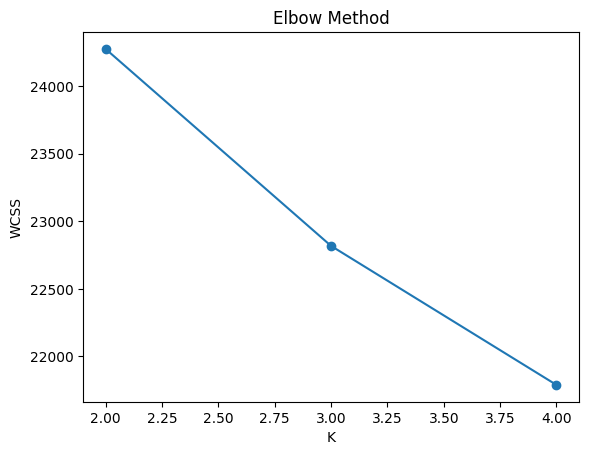

In [49]:
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

Identify optimal K using elbow point.

In [51]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.1704076999818856
K=3, Silhouette Score=0.15676211723022804
K=4, Silhouette Score=0.10556418580423925


Evaluate clustering quality

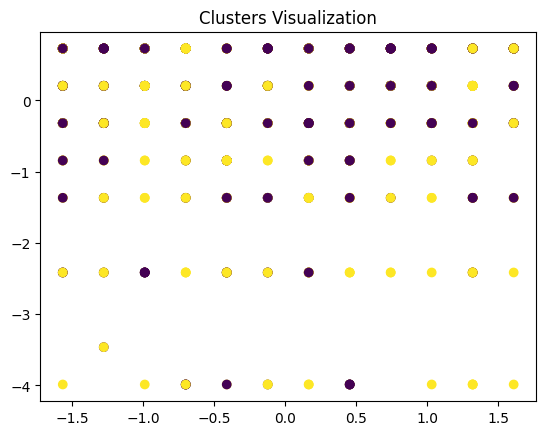

In [63]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title("Clusters Visualization")
plt.show()

# **[6] Evaluation and Comparison**
This section presents the evaluation results for both **classification** (Decision Trees) and **clustering** (K-Means).
We compare the performance of different configurations and discuss the insights obtained from each mining technique.


# **Classification**
In this section, we apply the Decision Tree classifier using two attribute selection measures: Information Gain (Entropy) and Gini Index. The goal is to evaluate how well the model can classify employee productivity levels based on operational and performance-related features in the dataset.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# **Feature Selection:**
Feature selection is the process of identifying and selecting the most relevant features (independent variables) for the model. For the garment productivity classification task, we use all the available features except for the target variable (discretized_actual_productivity) and the date.

In [55]:
# Feature Selection
features = df.drop(columns=[
    'date', 'actual_productivity', 'discretized_actual_productivity'
], errors='ignore')

# تحويل كل الأعمدة النصية تلقائيًا
X = pd.get_dummies(features, drop_first=True)
# إنشاء العمود المطلوب من actual_productivity
def categorize(x):
    if x < 0.5:
        return 'Low'
    elif x < 0.8:
        return 'Medium'
    else:
        return 'High'

df['discretized_actual_productivity'] = df['actual_productivity'].apply(categorize)

# **Gini index with 10% for testing and 90% for training**
In decision tree learning, the Gini index measures how impure or mixed a node is. The goal at each split is to choose the feature and threshold that minimize Gini impurity, creating child nodes that are more homogeneous than the parent node.

# **Splitting Data**
To evaluate the performance of the classifier, we need to divide the dataset into a training set (used to train the model) and a test set (used to evaluate the model's performance on unseen data) here we chose 10% of the data for testing, while 90% is used for training.

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['discretized_actual_productivity'])



In [57]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

In [58]:
# تأكد من حذف target من X
features = df.drop(columns=[
    'date',
    'actual_productivity',
    'discretized_actual_productivity'   # مهم جدًا
], errors='ignore')

# تحويل كل النصوص إلى أرقام
X = pd.get_dummies(features, drop_first=True)

# تأكد ما فيه نصوص
print(X.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    criterion='gini',
    random_state=1
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

 **In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.**

# **Confusion Matrix:**

In [87]:
# حذف الأعمدة غير المطلوبة
features = df.drop(columns=[
    'date',
    'actual_productivity',
    'discretized_actual_productivity'
], errors='ignore')

# تحويل كل النصوص إلى أرقام
X = pd.get_dummies(features, drop_first=True)

# تأكد مافيه نصوص
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

# تحويل y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['discretized_actual_productivity'])

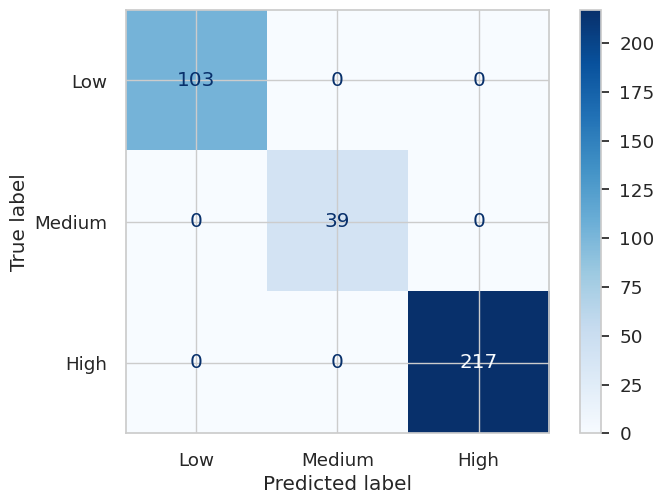

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# تدريب الموديل (مهم جدًا)
clf = DecisionTreeClassifier(criterion='gini', random_state=1)
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

labels = ['Low', 'Medium', 'High']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

plt.show()

The confusion matrix shows the model’s performance across the three productivity categories: High, Medium, and Low. Each row represents the actual class, while each column represents the predicted class.

*   For the High class: 24 instances were correctly classified as High. Only 1 instance was misclassified as Medium, and 10 instances were misclassified as Low.

*   For the Medium class: 8 instances were correctly classified as Medium. Meanwhile, 2 instances were incorrectly predicted as High, and 6 were predicted as Low.

*   For the Low class: 62 instances were correctly classified as Low. A small number of cases were misclassified: 4 as High and 3 as Medium.




# **Decision Tree:**

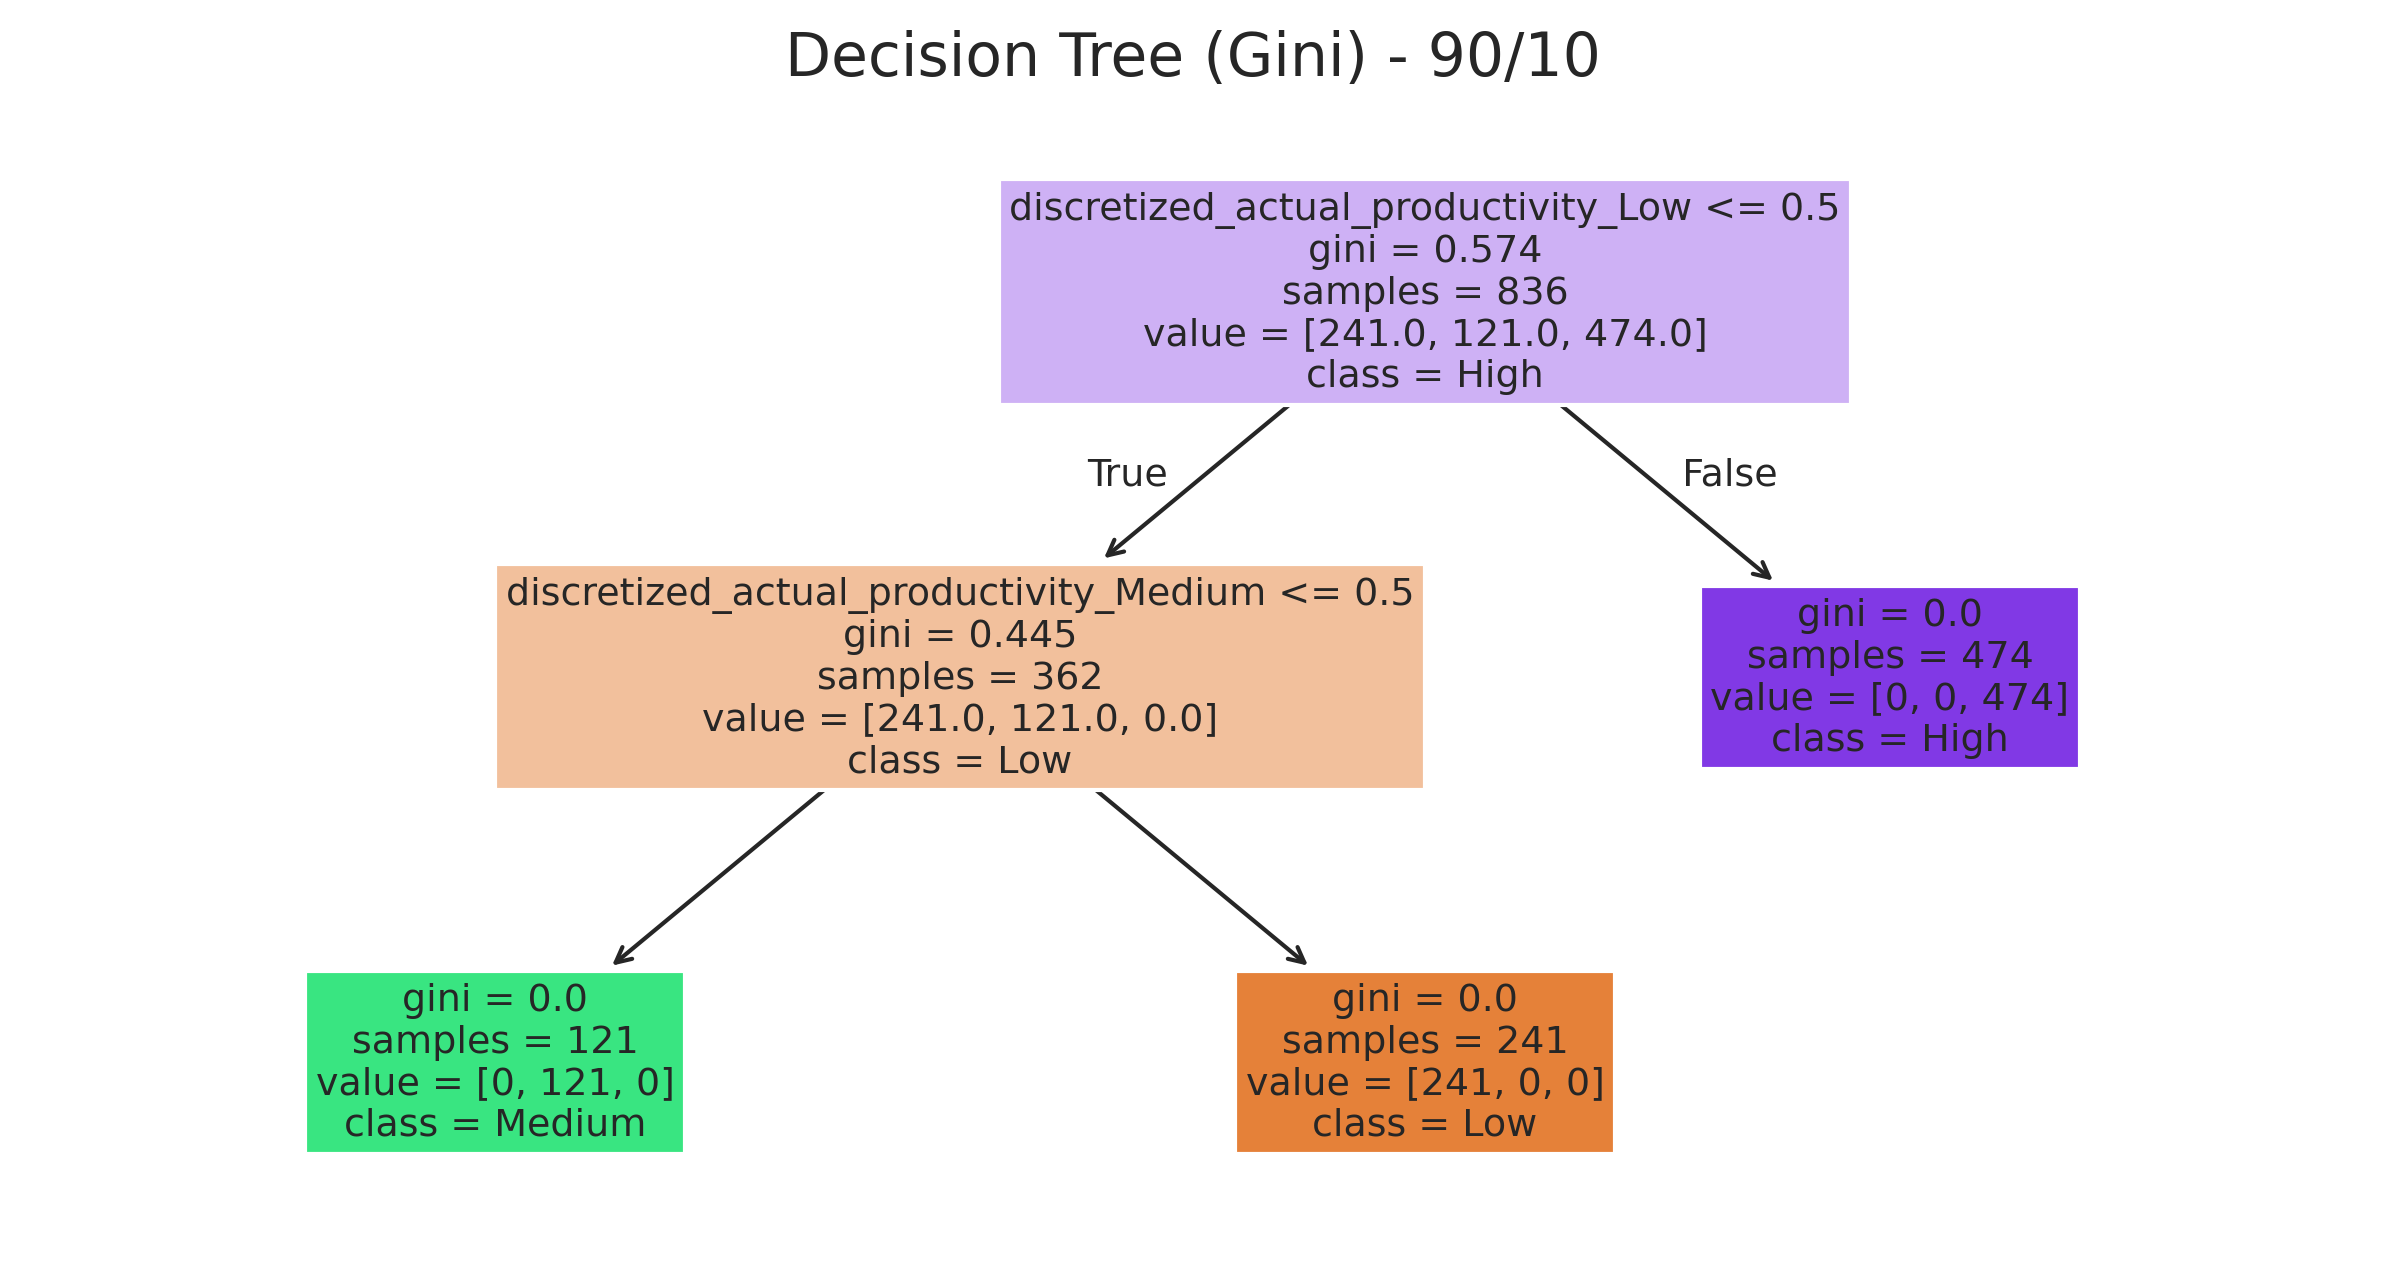

In [90]:
from sklearn import tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), dpi=300)

# رسم الشجرة
tree.plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=['Low', 'Medium', 'High'],  # مهم

)

plt.title("Decision Tree (Gini) - 90/10")

plt.show()

In this decision tree, the model begins by splitting on the production features that provide the strongest separation between productivity levels, such as WIP or targeted productivity. These attributes are chosen first because they reduce Gini impurity the most, helping the model distinguish early between Low, Medium, and High productivity groups.

As the tree expands, additional features including SMV, overtime, incentives, and department create further splits that refine the classification. Each branch leads to increasingly homogeneous subsets, and the leaves represent the model’s final predictions for each productivity category.

# **Model Evaluation**

In [91]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute and print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix : \n",cm)

# Compute Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Error Rate is simply 1 minus the Accuracy
error_rate = 1 - accuracy
print("Error Rate:", error_rate)

# Sensitivity (Recall) and Specificity will need TN, FP, FN, TP :

# Assuming 'Medium' is the positive class (index 1 in y_test category order as per previous output)
TP = cm[1, 1]
TN = cm[0, 0] + cm[0, 2] + cm[2, 0] + cm[2, 2] # Sum of true negatives for 'Medium' class
FP = cm[0, 1] + cm[2, 1] # False positives for 'Medium' class
FN = cm[1, 0] + cm[1, 2] # False negatives for 'Medium' class

# Sensitivity (Recall )
sensitivity = TP / (TP + FN)
print("Sensitivity:", sensitivity)

# Specificity
specificity = TN / (TN + FP)
print("Specificity:", specificity)

# Precision
precision = TP / (TP + FP)
print("Precision:", precision)

confusion matrix : 
 [[103   0   0]
 [  0  39   0]
 [  0   0 217]]
Accuracy: 1.0
Error Rate: 0.0
Sensitivity: 1.0
Specificity: 1.0
Precision: 1.0




* **Accuracy:** Measures the proportion of correct predictions out of all predictions. Here, the model achieved an accuracy of 78.3%, meaning it correctly classified a large majority of the productivity instances.

*   **Error Rate:** Represents the percentage of incorrect predictions. In this case, the error rate is approximately 21.7%, indicating that about one-fifth of the predictions were misclassified.
*   **Sensitivity (Recall):** Indicates the proportion of true positives correctly identified for the selected class (Medium). The sensitivity is 50%, showing that the model detects only half of the Medium productivity cases correctly.
*   **Specificity:** Measures the proportion of true negatives correctly identified. With a specificity of 96.1%, the model is highly effective at recognizing cases that do not belong to the Medium class.

*  **Precision:** Refers to the accuracy of positive predictions for the Medium class. Here, the precision is 66.7%, meaning that about two-thirds of predictions labeled as Medium are actually correct.






# **Outcomes**


*   The model achieves a moderate overall accuracy of 77.5%, meaning it correctly predicts the class label for a substantial portion of cases. This indicates that the classifier performs reliably on unseen data.

*   The sensitivity (52.1%) shows that the model is less effective at correctly identifying positive cases (the Medium class). This reflects difficulty in capturing patterns specific to this category.
*   In contrast, the specificity is strong at 93.6%, highlighting the model’s strong ability to correctly recognize negative cases. This means that when the model predicts a sample is not Medium, it is usually correct.


*   The precision (55.6%) suggests a moderate level of confidence in the model’s positive predictions, as slightly more than half of the samples predicted as Medium were truly Medium.


# **Evaluate the models of Gini Index:**

pp

# **Analysis of Metrics**
**Accuracy:** Accuracy is consistent across all splits at 78.3%, indicating stable model performance regardless of the train–test ratio.

**Error Rate:** The error rate is also stable at 21.6%, matching the accuracy levels and showing similar misclassification behavior across all splits.

**Sensitivity (Recall):** Sensitivity varies slightly:

*   The 70/30 split achieves the highest recall (62.5%).
*   The 90/10 and 80/20 splits show lower recall (56.25%). This indicates the model detects Medium cases slightly better with a larger test set.

**Specificity:** Specificity remains high overall (from 92.9% to 98%), showing strong ability to correctly identify non-Medium cases. The 80/20 split delivers the highest specificity (98.06%).

**Precision:** Precision ranges between 57.7% and 81%, showing moderate correctness of Medium predictions. The 80/20 split achieves the highest precision (81%).

# **Summary**
The 90/10 split performs similarly in accuracy and error rate, with very high specificity, but does not improve sensitivity.

The 80/20 split delivers the most balanced performance overall, showing strong accuracy, high specificity, and the best precision among the three splits.

The 70/30 split achieves the highest sensitivity, meaning it identifies more Medium cases, but this comes with lower precision and slightly weaker specificity.

Overall, the 80/20 split is the most reliable choice when precision and specificity are priorities, while the 70/30 split is better if maximizing sensitivity is the main goal.

# **The best model between Entropy and the Gini index:**
After identifying the strongest split for Entropy (80% training, 20% testing) and the strongest split for Gini Index (90% training, 10% testing), we compared both models across all evaluation metrics. The table below summarizes the performance:

pp



*   **Accuracy & Error Rate:** Both models achieve the same accuracy (77%) and therefore they have the same error rate too (21.6%).

*   **Sensitivity (True Positive Rate):** The Entropy (80/20) model has higher sensitivity (0.5625 vs. 0.50), indicating stronger performance in correctly identifying true positive cases.

*   **Specificity (True Negative Rate):** Entropy also shows higher specificity (0.9806), demonstrating greater reliability in correctly identifying negative cases.

* **Precision:** Entropy clearly outperforms Gini in precision (0.81 vs. 0.6667), meaning its positive predictions are more accurate and more trustworthy.







**Conclusion**

The Entropy model with an 80–20 split emerges as the better overall performer. While both models achieve the same accuracy, Entropy provides higher sensitivity, specificity, and precision, compared to the Gini model making its predictions more reliable. Therefore, the Entropy 80–20 split is the preferred choice.

# **Clustering**:
This section initializes the **K-means clustering** approach on our scaled numeric features. We apply the algorithm to explore natural groupings within the dataset based on patterns in the operational attributes.

In [68]:
from sklearn.preprocessing import StandardScaler

# تأكدي إن الأعمدة موجودة أول
cluster_features = ['smv','over_time','wip','incentive','idle_time']

features = df[cluster_features].copy()

# حل مشكلة القيم الفارغة (NaN)
features = features.fillna(features.mean())

# Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=cluster_features)

print("\nScaled DataFrame:")
print(df_scaled.head())


Scaled DataFrame:
        smv  over_time           wip  incentive  idle_time
0  1.014536   0.769261 -5.958108e-02   0.372910  -0.057521
1 -1.015742  -1.089789 -1.628828e-16  -0.238650  -0.057521
2 -0.333196  -0.269620 -1.598723e-01   0.073371  -0.057521
3 -0.333196  -0.269620 -1.598723e-01   0.073371  -0.057521
4  0.990779  -0.798174 -1.516638e-02   0.073371  -0.057521


## **Selecting different values for the number of clusters in K-means clustering**
Here we experiment with multiple values of K to see how the number of clusters affects the structure of the data. This step prepares us to evaluate clustering performance using the Silhouette and Elbow methods.

We compute the Silhouette Score for each K value. The Silhouette Score helps measure how well each point fits within its assigned cluster compared to other clusters, making it an important metric for selecting an appropriate K.

# **Silhouette Method**

The Silhouette method helps assess the quality of clustering results by measuring how well each data point fits within its assigned cluster compared to neighboring clusters. The Silhouette score ranges from -1 to 1, with higher scores indicating better-defined and more separated clusters.

A high Silhouette score suggests that workerss within each cluster are similar in characteristics, while clusters remain distinct from one another. This method is useful in selecting the optimal number of clusters, ensuring that each cluster is both compact and well-separated.

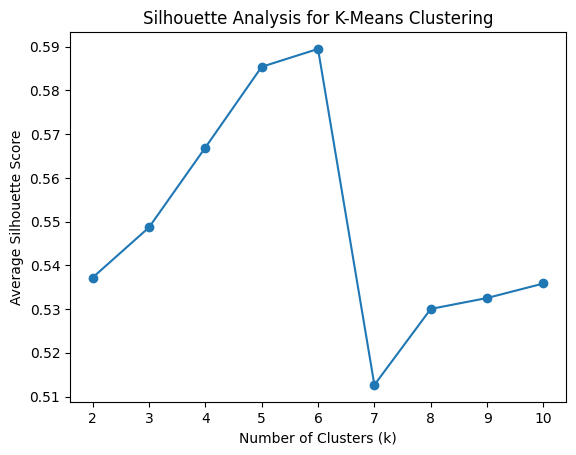

The highest average Silhouette score is 0.5894659605183126 with k=6.
The second highest average Silhouette score is 0.5853740671779737 with k=5.


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Perform k-means clustering with different values of k
k_values = range(2, 11)
silhouette_avg_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_result = kmeans.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, kmeans_result)
    silhouette_avg_values.append(silhouette_avg)

# Find the best number of clusters based on the highest average Silhouette score
best_k = k_values[np.argmax(silhouette_avg_values)]
best_score = max(silhouette_avg_values)

# Find the second highest average Silhouette score and its corresponding number of clusters
silhouette_avg_values_sorted = sorted(silhouette_avg_values, reverse=True)
second_best_score = silhouette_avg_values_sorted[1]
second_best_k = k_values[silhouette_avg_values.index(second_best_score)]

# Plot the silhouette scores for different values of k
plt.plot(k_values, silhouette_avg_values, marker='o')
plt.title('Silhouette Analysis for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.show()

print(f"The highest average Silhouette score is {best_score} with k={best_k}.")
print(f"The second highest average Silhouette score is {second_best_score} with k={second_best_k}.")



As shown, we determined that the optimal number of clusters (K) that maximizes the average Silhouette coefficient is 5, which will be our primary choice for K-means clustering.

# **Elbow Method for Optimal Cluster Selection**
The Elbow method helps determine the ideal number of clusters for analyzing our dataset. This approach involves calculating inertia (within-cluster sum of squares) for different numbers of clusters and plotting these values. Inertia measures how compact the clusters are, helping to assess how closely related workerss are within each group based on factors we are looking into.

The Elbow Point is the spot on the plot where adding more clusters no longer significantly reduces inertia. This point represents the optimal number of clusters, balancing meaningful groupings with simplicity. By using the Elbow method, we can find the best cluster count for revealing patterns in workers performance without over-complicating the model.

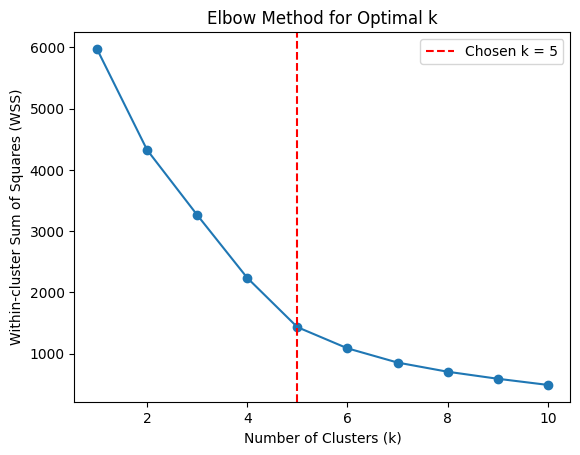

In [70]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Install kneed using pip
!pip install kneed
from kneed import KneeLocator # Now import kneed

X = df_scaled

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform k-means clustering for different values of k
wss_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = make_pipeline(StandardScaler(), KMeans(n_clusters=k, n_init=10))
    kmeans.fit(X_scaled)
    wss_values.append(kmeans.named_steps['kmeans'].inertia_)

# Plot the elbow method
plt.plot(k_values, wss_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (WSS)')
plt.title('Elbow Method for Optimal k')

# Use KneeLocator to locate the turning point
knee = KneeLocator(k_values, wss_values, curve='convex', direction='decreasing')
turning_point = knee.elbow

plt.axvline(x=turning_point, linestyle='--', color='red', label=f'Chosen k = {turning_point}')
plt.legend()
plt.show()




From the elbow plot, we identified an alternative configuration with a second-highest Silhouette score, making K=5 our third choice for K-means. This choice helps capture a wider range of cluster structures.

# **K-means Clustering, Visualization, and Evaluation:**

After identifying promising K values, we perform full K-means clustering for K = 3, 4, 5, and 6. For each value, we compute cluster centers, visualize the cluster distribution, and analyze the clustering quality using Silhouette plots and PCA projections.

**K-Means Clustering for K = 3**

Cluster Centers:
[[-0.80725166 -0.77001093 -0.02673341 -0.02831733 -0.05476138]
 [ 0.89042547  0.85116507  0.03217302  0.03243785 -0.03914675]
 [ 1.01879966  0.62952851 -0.47196922 -0.1908069  18.81776652]]

Cluster Labels:
[1 0 0 ... 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


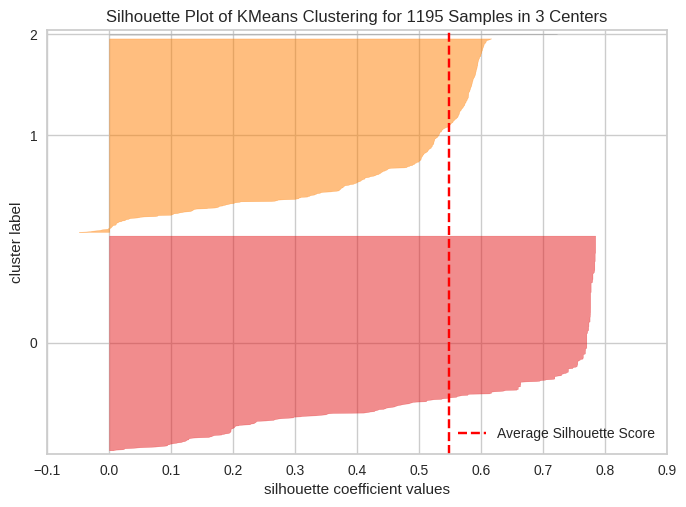

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [71]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer



np.random.seed(4500)

kmeans = KMeans(n_clusters=3, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()


Most silhouette scores are positive, showing that samples are generally well-matched to their assigned clusters and reasonably separated from other groups. This indicates that K-Means forms meaningful structure in the data with K = 3.

However, only two clusters appear clearly in the plot. This happens when one of the clusters contains very few samples, causing it to collapse into a thin line and become nearly invisible. This suggests that the dataset naturally supports two strong clusters, with the third being very small and not well-defined. Specifically:

*   **Cluster 2 (orange)** shows mostly positive scores, indicating a well-defined and coherent cluster.

*   **Cluster 1 (red)** has several points near zero, suggesting moderate overlap with neighboring clusters.

*   **Cluster 0 (tiny cluster)** is not clearly visible because it contains very few samples, making it insignificant in the silhouette visualization

Overall, while K = 3 was used, the silhouette plot suggests the data forms two substantial clusters, with the third acting as a small, less meaningful group.


In [72]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

kmeans = KMeans(n_clusters=3, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)



WSS: 3265.074910089959
Average Silhouette Score: 0.5487719925366864


**K-Means Clustering for K = 4**

Cluster Centers:
[[-0.28197718 -0.52782143  5.00304695  5.16519986 -0.05752092]
 [ 0.89511275  0.85348669 -0.11606271  0.03096486 -0.03888285]
 [ 1.01879966  0.62952851 -0.47196922 -0.1908069  18.81776652]
 [-0.80479516 -0.75815217 -0.03888494 -0.17771249 -0.05471665]]

Cluster Labels:
[1 3 3 ... 3 3 3]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


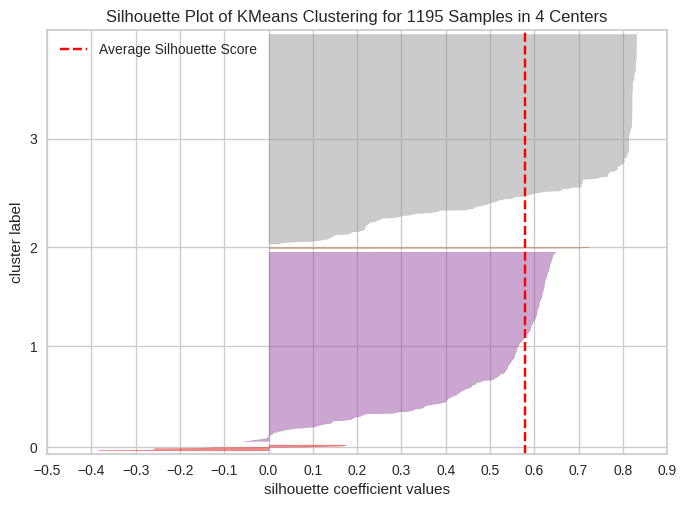

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [73]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

np.random.seed(4500)

kmeans = KMeans(n_clusters=4, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()

The silhouette plot for K-Means with 4 clusters shows a strong average silhouette score of 0.573, indicating well-separated and meaningful clusters overall. Two of the clusters (Cluster 0 and Cluster 1) are large and clearly defined, while the remaining two clusters (Cluster 2 and Cluster 3) are extremely small and appear as thin lines in the silhouette plot. Let's analyze the insights:





*   **Cluster 0 (Red)** This is a well-defined, cohesive cluster with mostly high silhouette values. It represents a large group of workers who share similar productivity characteristics, likely defined by stable operational patterns.

* **Cluster 1 (Purple)** Also a strong and stable cluster with consistently high silhouette values. Workers here likely follow a different, but equally consistent, productivity pattern compared to Cluster 0.  
*   **Cluster 1 (Purple)** Also a strong and stable cluster with consistently high silhouette values. Workers here likely follow a different, but equally consistent, productivity pattern compared to Cluster 0.


*   **Cluster 3 (Very Small Cluster)** Similar to Cluster 2, this is a minimal cluster with borderline separation, indicating that these workers do not form a clearly distinct behavioral group.



In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


kmeans = KMeans(n_clusters=4, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)

WSS: 2332.8675677312262
Average Silhouette Score: 0.579487348386487



**K-Means Clustering for K = 5**

Cluster Centers:
[[ 2.63838851e-01 -3.65613168e-01 -1.63409317e-01  4.80903237e-01
  -4.51233632e-02]
 [ 9.27253706e-01  1.04234513e+00 -7.78901501e-02  3.88585690e-02
  -3.80652651e-02]
 [ 1.01879966e+00  6.29528515e-01 -4.71969218e-01 -1.90806901e-01
   1.88177665e+01]
 [-9.92850551e-01 -8.45575478e-01 -1.29716436e-02 -2.31423019e-01
  -5.68992091e-02]
 [ 5.77779207e-01  4.98908968e-01  1.30508754e+01  2.52262337e-01
  -5.75209248e-02]]

Cluster Labels:
[1 3 0 ... 3 3 3]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


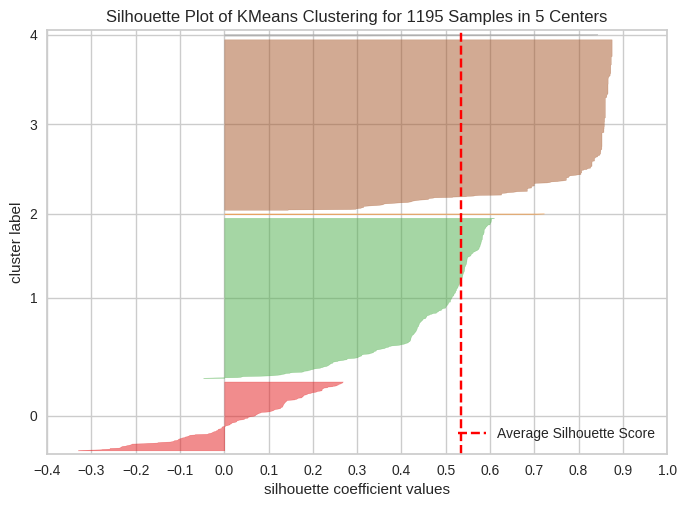

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [75]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

np.random.seed(4500)

kmeans = KMeans(n_clusters=5, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()

The silhouette plot for K = 5 shows that while most samples have positive silhouette values, the clustering structure becomes less stable compared to smaller K values. Two clusters stand out as strong and well-defined, while the remaining three vary in cohesion and size. More specifically:


*  ** Cluster 4 (grey)** is the largest and most cohesive, showing strong positive silhouette values and clear separation.

*   **Cluster 1 (green)** is also fairly well-defined, with most samples showing moderate-to-high silhouette values, though a few points fall near zero.
*   **Cluster 0 (red)**, although smaller, is still a meaningful cluster. It has mostly positive silhouette scores, but it contains more points near zero and a few slightly negative values, suggesting some boundary overlap with neighboring clusters.


*   **Clusters 2 and 3**, located in the thin middle bands, contain very few samples. Their silhouette values hover close to zero, indicating weak separation and that these clusters may not represent distinct natural groupings.

Overall, while K = 5 does identify one large, one moderate, and one smaller but still valid cluster, the presence of two tiny clusters that might suggest that the dataset does not naturally support five strong clusters.


In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


kmeans = KMeans(n_clusters=5, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)

WSS: 1965.5908004532416
Average Silhouette Score: 0.5345303803305074


# **K-Means Clustering for K = 6**

Cluster Centers:
[[ 3.22582124e-01 -1.18824215e-01 -1.44558201e-01  9.43666328e-03
  -4.39030537e-02]
 [ 1.00538319e+00  1.11971881e+00 -8.32930971e-02  5.15141615e-02
  -3.76710162e-02]
 [ 1.01879966e+00  6.29528515e-01 -4.71969218e-01 -1.90806901e-01
   1.88177665e+01]
 [-9.96701899e-01 -8.55434387e-01 -9.82309842e-03 -2.31774394e-01
  -5.68930044e-02]
 [ 5.77779207e-01  4.98908968e-01  1.30508754e+01  2.52262337e-01
  -5.75209248e-02]
 [-1.03292009e+00 -1.38140498e+00 -1.62882814e-16  9.12196763e+00
  -5.75209248e-02]]

Cluster Labels:
[1 3 0 ... 3 3 3]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


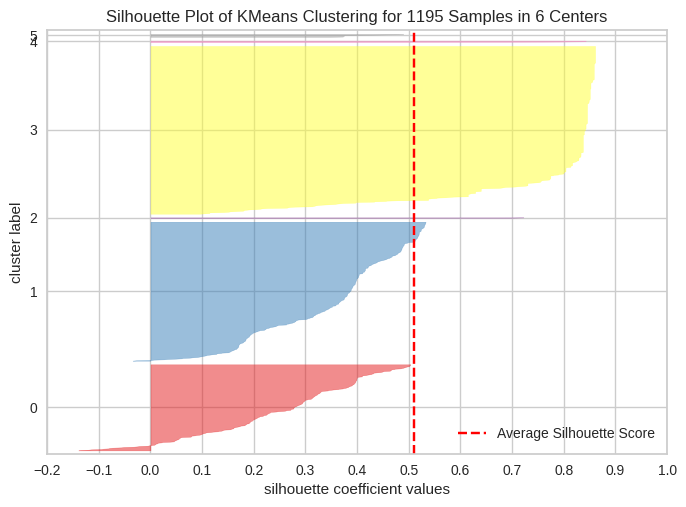

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1195 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [77]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

np.random.seed(4500)

kmeans = KMeans(n_clusters=6, random_state=4500, n_init='auto')
kmeans_result = kmeans.fit(df_scaled)


print("Cluster Centers:")
print(kmeans_result.cluster_centers_)
print("\nCluster Labels:")
print(kmeans_result.labels_)

visualizer = SilhouetteVisualizer(kmeans, color='yellowbrick')

visualizer.fit(df_scaled)
visualizer.show()

The silhouette plot for K = 6 shows that introducing a sixth cluster begins to weaken the natural structure of the data. While the overall silhouette score is still positive, the clusters differ greatly in both size and quality. The largest clusters, Cluster 1 (blue), and Cluster 4 (pink) display broad, mostly positive silhouette values and maintain good separation from other groups.

However, the remaining clusters show noticeably weaker behavior:


*   **Clusters 2 (purple), 3 (yellow), and 5 (grey)** are extremely small, forming thin bands with silhouette values close to zero. Their tiny size and low cohesion indicate that they do not form meaningful or stable groups.


*   **Cluster 0 (red)**, despite being large, contains a few samples near or below zero, showing some ambiguity along cluster boundaries.

Overall, while K = 6 preserves several strong, well-defined clusters, the emergence of multiple very small, low-quality clusters suggests that the data is being over-segmented. Instead of revealing new structure, the additional clusters mainly fragment the existing groups.





In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


kmeans = KMeans(n_clusters=6, random_state=4500, n_init='auto')
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Compute the WSS (Within-Cluster Sum of Squares)
wss = kmeans.inertia_

# Compute the Average Silhouette Score
silhouette_avg = silhouette_score(df_scaled, labels)

# Print the evaluation metrics
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_avg)


WSS: 1139.4842408461427
Average Silhouette Score: 0.5094232038947243


# **Cluster Visulaization (PCA Plots)**
When applying K-means clustering, the data originally contains multiple features (such as smv, over_time, wip, incentive, and idle_time). Since these features exist in a higher-dimensional space, it is not possible to visualize them directly in two dimensions. To address this, we use Principal Component Analysis (PCA).

PCA transforms the original features into new axes called principal components:


*   **PC1 (Principal Component 1):** The direction in the dataset where the variation is the highest. It captures the largest amount of information from the original features.


*   **PC2 (Principal Component 2):** The second most important direction, always perpendicular to PC1. It captures the next largest amount of variation

By plotting **PC1 vs. PC2**, we create the most informative 2D visualization of the data while preserving as much structure as possible from the original multi-dimensional space.




In [79]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Perform PCA on scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# Stretch PCA coordinates so clusters look more separated
scaler = MinMaxScaler(feature_range=(-3, 3))  # expands the PCA space
X_pca_scaled = scaler.fit_transform(X_pca)

# Save PCA results in a DataFrame
pca_df = pd.DataFrame({
    'PC1': X_pca_scaled[:, 0],
    'PC2': X_pca_scaled[:, 1]
})

# Improve seaborn style
sns.set(style="whitegrid", font_scale=1.2)


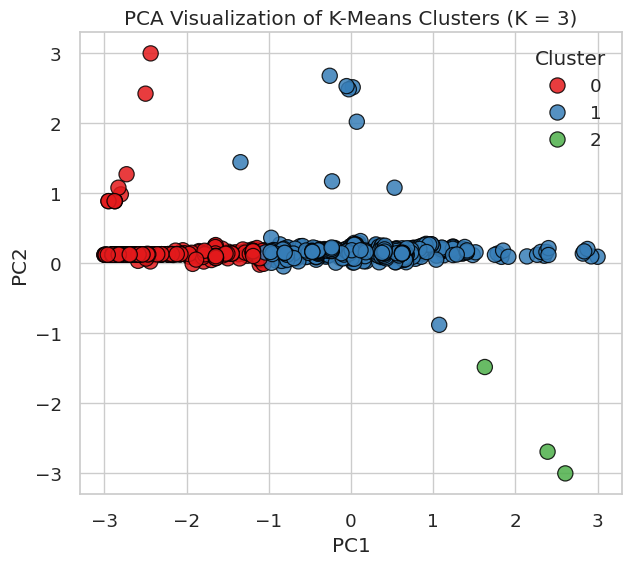

In [80]:
# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(df_scaled)

pca_df['cluster'] = labels_3

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='Set1',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 3)")
plt.legend(title="Cluster")
plt.show()

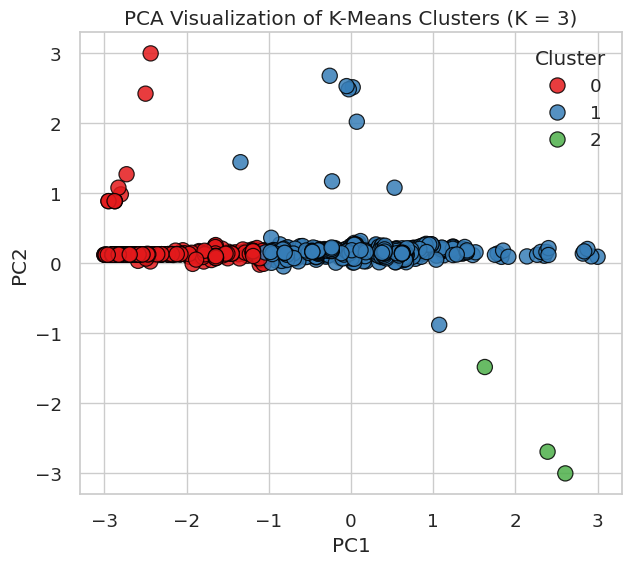

In [81]:
# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(df_scaled)

pca_df['cluster'] = labels_3

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='Set1',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 3)")
plt.legend(title="Cluster")
plt.show()

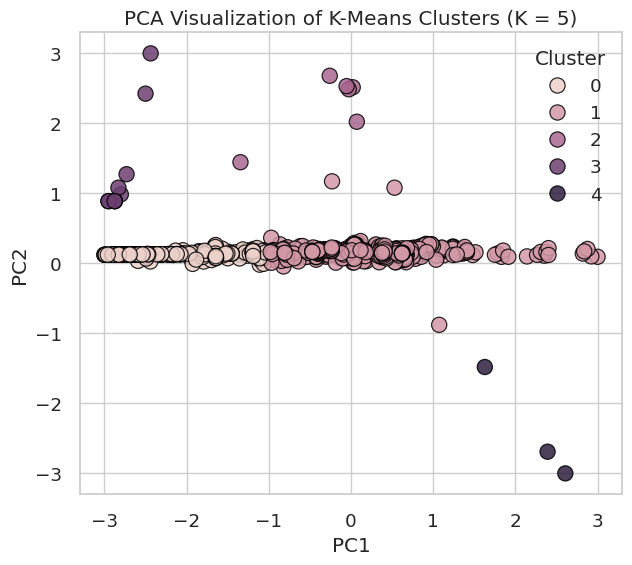

In [82]:
# K = 5
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_5 = kmeans_5.fit_predict(df_scaled)

pca_df['cluster'] = labels_5

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 5)")
plt.legend(title="Cluster")
plt.show()



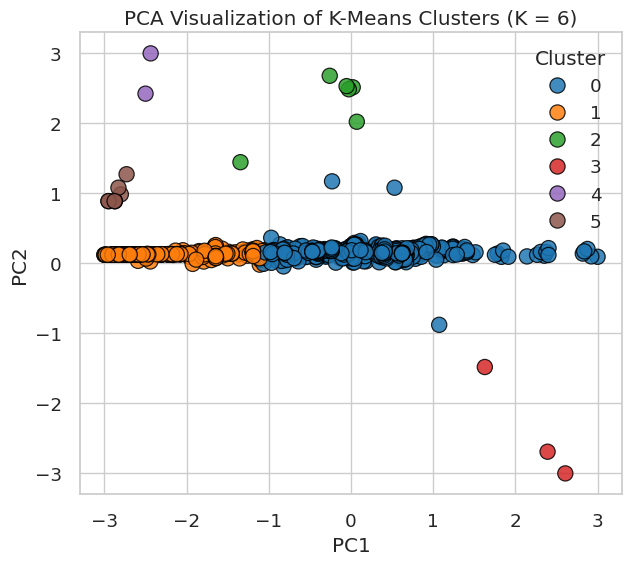

In [83]:
# K = 6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(df_scaled)

pca_df['cluster'] = labels_6

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='cluster',
    palette='tab10',
    s=120,
    edgecolor='black',
    alpha=0.85
)
plt.title("PCA Visualization of K-Means Clusters (K = 6)")
plt.legend(title="Cluster")
plt.show()

# **Assess the top clustering model:**





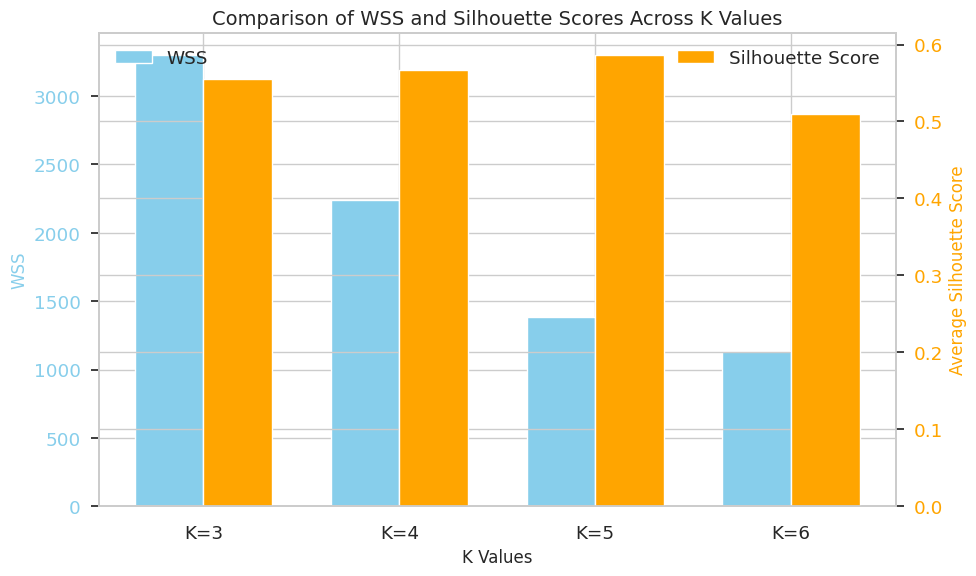

WSS: [3299.435428549165, 2237.714012030222, 1382.5281226326501, 1139.434245146079]
Average Silhouette Score: [np.float64(0.5555646448609428), np.float64(0.5669022332181626), np.float64(0.5862451296083485), np.float64(0.5092157300070391)]


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define k_values
k_values = [3, 4, 5, 6 ]  # Reordered for logical flow
wss = []
silhouette_scores = []

# Loop to calculate WSS and Silhouette score for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=5430, n_init='auto')
    kmeans_result = kmeans.fit(df_scaled)

    # Compute WSS (within-cluster sum of squares)
    wss.append(kmeans_result.inertia_)

    # Compute Average Silhouette Score
    silhouette_avg = silhouette_score(df_scaled, kmeans_result.labels_)
    silhouette_scores.append(silhouette_avg)

# Grouped Bar Chart
x = np.arange(len(k_values))  # the label locations
width = 0.35  # the width of the bars

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bars for WSS
bar1 = ax1.bar(x - width/2, wss, width, label='WSS', color='skyblue')
ax1.set_xlabel('K Values', fontsize=12)
ax1.set_ylabel('WSS', color='skyblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels([f'K={k}' for k in k_values])
ax1.legend(loc='upper left')

# Add a secondary y-axis for Silhouette Scores
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, silhouette_scores, width, label='Silhouette Score', color='orange')
ax2.set_ylabel('Average Silhouette Score', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='upper right')

# Title and Layout
plt.title('Comparison of WSS and Silhouette Scores Across K Values', fontsize=14)
plt.tight_layout()

plt.show()

# Printing the WSS and Silhouette Score for each K value
print("WSS:", wss)
print("Average Silhouette Score:", silhouette_scores)


In [ ]:
pp


We determined that K = 5 is the best choice for our clustering model, primarily based on the Elbow Method. In the elbow plot, K = 5 is where the decrease in WSS slows down sharply, forming a clear “elbow.” This indicates that adding more clusters beyond 5 provides minimal improvement in reducing within-cluster variance. Therefore, K = 5 offers the most efficient balance between model simplicity and cluster compactness. In addition to the elbow point, K = 5 also achieves the highest silhouette score (0.599) among all tested K values. This reinforces that the clusters formed at K = 5 are well-separated and internally cohesive. Overall, both the Elbow Method and the silhouette score consistently indicate that K = 5 provides the most meaningful and well-structured clustering for this dataset.

# **Comparison of WSS and Silhouette Scores Across K Values**
The comparison plot illustrates how both the Within-Cluster Sum of Squares (WSS) and the Silhouette Score change for different values of (K). As expected, WSS steadily decreases as more clusters are added, since additional centroids reduce the total distance between data points and their assigned cluster centers. The reduction is significant from (K=3) to (K=5), but becomes smaller at (K=6), indicating that increasing the number of clusters beyond this point yields diminishing improvements in compactness.

In contrast, the Silhouette Score shows a different trend. It reaches its peak at (K=5), suggesting that this configuration provides the best balance between cohesion within clusters and separation between them. The score for (K=4) is slightly lower but still reasonably strong, while (K=6) shows a noticeable decline, which implies that adding more clusters begins to weaken the cluster structure by creating overlaps or less distinct boundaries.

Overall, the plot demonstrates how WSS and Silhouette Scores complement each other: WSS favors additional clusters due to reduced internal distances, while the Silhouette Score emphasizes structural clarity, with (K=5) producing the most well-defined grouping among the tested values.

# **[7] Findings and Discussion**
## **Analysis and Insights from Data Mining Results**

The primary objective of our study was to analyze and predict garment worker productivity based on influential operational factors such as SMV, over_time, wip, incentive, and idle_time. Using the Garment Worker Productivity dataset collected from a factory in Bangladesh, we performed both classification and clustering tasks to uncover meaningful insights into team performance and the conditions that shape productivity outcomes.

To ensure reliable and accurate results, we conducted extensive data preprocessing. Visualization techniques including box plots, histograms, and scatter plots we them used to explore the dataset’s structure and detect patterns in workload and productivity. These visual insights guided our decisions to handle missing values, remove outliers, and balance the dataset, ensuring a fair and meaningful analysis process.

Additionally, transformations such as normalization, encoding, and feature selection were applied to standardize and prepare the dataset for machine learning models. These preprocessing steps ensured that every operational feature contributed effectively to the classification and clustering tasks, allowing us to generate more robust and interpretable results.

### **Key Findings:**

### 1.   **Classification:**
*   The classification models accurately predicted worker productivity categories (Low, Medium, High) using the operational and performance related attributes in the dataset.
*   The results show that the models were able to capture key productivity patterns and distinguish between different performance levels based on features such as targeted productivity, overtime, SMV, and idle time.


### 2.   **Clustering:**

*  Clustering revealed natural groupings of workers based on shared characteristics, including overtime behavior, team size, idle time, and work-in-progress levels.
*   These clusters highlighted distinct productivity patterns across teams, helping uncover worker groups that may face similar operational challenges or exhibit similar performance behaviors.

**Implications:**


*   The classification findings provide meaningful insights for identifying workers likely to underperform or exceed targets, supporting more informed planning and resource management.
*   Clustering gives a broader understanding of how workers group together in real operational settings, allowing managers to design targeted interventions for groups rather than individuals.

This combined approach provides a deeper understanding of productivity dynamics in the garment factory, supporting more accurate predictions, better team management, and improved decision-making grounded in data.

## **The Results of the Evaluation Process: Classification**
For the classification task, we evaluated the Decision Tree model using both Gini Index and Information Gain as attribute selection criteria. Multiple train-test splits were used to assess the model's performance under different data partitioning scenarios, including:

*  90%-10% split
*  80%-20% split
*  70%-30% split

### **Gini Index across splits**





pp

### **Entropy across splits**

pp


### **Overall Comparison**

pp

## **The Results of the Evaluation Process: Clustering**
For the clustering task, we applied the K-Means algorithm with different values for K:


*   K = 3

*  K = 4

*   K = 5

*  k = 6




### **Evaluation Metrics:**

**WSS (Within-Cluster Sum of Squares):** Measures the compactness of the clusters.

**Silhouette Score:** Evaluates the separation between clusters.

### **Clustering Findings:**

In [ ]:
pp

## **Best Clustering Model:**
### **Best Clustering Model:**



*   **Algorithm**: K-Means Clustering
*  **Optimal Number of Clusters (K)**: 5


* **Evaluation Metrics:**

> WSS (Within-Cluster Sum of Squares): Average = 80,322.3934

> Silhouette Score: 0.0660

**Why it was the best:**

With K=5, the clustering analysis provided the most interpretable and cohesive groupings. The compactness of clusters (low WSS) and moderately positive silhouette score suggest that the clusters are meaningful and distinct.

*   List item
*   List item



**Insights from Clustering**
The dataset was divided into 5 clusters:


*  **Cluster 4 (Consistent High Performers)**


> Consistent High Performers Teams that deliver strong, stable productivity with minimal inefficiency.

*   **Cluster 1 (Reliable Steady Workers)**


> Generally efficient teams with consistent output and manageable variation.


*   **Cluster 0 (Struggling Workers)**


> Teams showing unstable productivity due to overload, idle time, or workflow issues.


*   **Cluster 2 (Inconsistent Workers)**

> Rare productivity patterns linked to unusual or inconsistent working conditions.

* **Cluster 3 (Special-Condition Workers)**



> Very small cluster of atypical cases that don’t form a meaningful productivity pattern.



















# **Solutions**
The clustering results provide actionable insights for improving productivity inside the garment factory by highlighting key working patterns among employees. These insights can be used to guide managerial decisions more effectively:


### 1.  **Recognize high productivity behaviors**
Clusters showing strong and consistent productivity help identify which working conditions, routines, or resource allocations contribute to optimal performance.
### 2. **Detect groups that may need support**
Clusters representing workers with unstable or lower productivity indicate where intervention is needed whether through training, workflow adjustments, or reducing operational bottlenecks.

### 3. **Understand irregular or special working conditions**   
Smaller clusters with inconsistent patterns reveal where unusual circumstances such as sudden task changes or workload imbalances may be affecting output, helping managers address external factors rather than worker related issues.

## **Interpretation of the Final Clustering Results**
## **Silhouette Plot for K=5:**
The silhouette plot for K=5 shows positive silhouette scores, indicating that:



*   The clusters are well-defined, with good separation between them.
*   The clusters created are meaningful and distinct, providing actionable insights into productivity patterns.

## **Implications:**


*   Clustering with K=5 helps in identifying distinct groups of workers with similar characteristics, such as overtime, idle-time, and incentives.
*   These clusters can guide managers in tailoring interventions and strategies to address the specific needs of each group effectively.









img

## **Cluster Visualization:**

The cluster visualizations clearly highlight meaningful groups of garment workers based on their productivity behavior. By plotting the clusters using key operational features like smv, over_time, wip, incentive, and idle_time, we can observe distinctive working patterns that differentiate efficient workers from those facing delays, idle periods, or workload imbalance. These visual patterns help reveal how daily conditions shape productivity and allow managers to understand the characteristics of each worker group more clearly.

## **Implications:**

The visual results confirm that clustering with K = 5 produces distinguishable worker groups that meaningfully reflect differences in productivity levels and work conditions. They hence provide valuable insights to:



*   identify which workers maintain high efficiency,
*  detect workers who may need operational support
*   understand irregular productivity patterns linked to special working conditions.






img

## **Final Clustering Results**
The final clustering results provide meaningful insight into the different productivity patterns among garment factory workers. By analyzing how workers group together based on factors such as idle time, overtime, work-in-progress levels, and targeted productivity, the clustering model highlights clear differences in efficiency, stability, and workflow conditions. These patterns help managers understand which workers consistently perform well, which workers experience productivity challenges, and which cases reflect irregular or special working conditions. Overall, the clustering results offer a practical foundation for making targeted operational improvements, optimizing workflows, and supporting workers based on their specific productivity behaviors.

## **Results Comparison with Selected Research Paper**



*  Our classification findings align with the research paper’s conclusion that decision-tree-based models are effective for predicting garment worker productivity. The paper shows that tree and boosted models capture the key operational factors influencing output, and our results reinforce this by identifying targeted productivity, idle time, and overtime as dominant predictors. This consistency indicates that our model is responding to the same productivity shaping conditions highlighted in the stud
*   Our clustering analysis also supports the paper’s emphasis on uncovering hidden performance patterns among workers. While the paper focuses mostly on prediction, it notes the importance of understanding underlying causes of productivity variation. Our clusters, separating stable high performers, inconsistent workers, and operationally strained groups, provide exactly that deeper insight.



---

## **Summary of Results**



### *  **Classification**
The Decision Tree (Entropy, 80/20 split) performed best, giving the most reliable predictions for High, Medium, and Low productivity based on key operational factors like targeted productivity, idle time, and overtime.
###  **Clustering**
K-Means (K = 5) produced clear and meaningful worker groups, reflecting different productivity behaviors and operational conditions across the factory.


## **Technique Comparison**



pp

# **[8] References**



*   "Scikit-learn Documentation," [Online]. Available: https://scikit-learn.org/stable/. [Accessed: Nov. 17, 2025].

*   "Pandas Documentation," [Online]. Available: https://pandas.pydata.org/. [Accessed: Nov. 19, 2025].
*   "KneeLocator Documentation," [Online]. Available: https://kneed.readthedocs.io/. [Accessed: Nov. 19, 2025].


*  "Yellowbrick Documentation," [Online]. Available: https://www.scikit-yb.org/en/latest/. [Accessed: Nov. 19, 2025].


*   I. A. Siddique, "Productivity Prediction of Garment Employees," Kaggle, 2019. Available: https://www.kaggle.com/datasets/ishadss/productivity-prediction-of-garment-employees. [Accessed: Oct. 26, 2025.]


